# E01 — Matrix Sensing Benchmark: Muon vs SGD

## Overview

This experiment establishes the baseline comparison between **Muon** (with spectral normalization via exact SVD) and **SGD** (with momentum 0.9) on the **Matrix Sensing** problem. Matrix sensing is a fundamental low-rank matrix recovery problem where the goal is to recover a rank-$r$ matrix $X^\star \in \mathbb{R}^{d \times d}$ from $m$ linear measurements.

**Why this matters**: Matrix sensing provides a clean optimization landscape (under RIP conditions) where both algorithms converge to the global optimum. This comparison reveals whether Muon's spectral normalization provides practical convergence advantages.

**Experiment ID**: E01 | **Problem Domain**: Matrix Sensing | **Algorithms**: Muon-Exact vs SGD

## Scientific Question

### Hypothesis
> Muon's spectral normalization achieves faster convergence (lower $K_\epsilon$) than SGD on matrix sensing, by equalizing gradient directions across singular values.

### Key Metrics
- **$K_\epsilon$**: Iterations to reach $\epsilon = 0.01$
- **min_loss**: Best loss achieved
- **final_loss**: Loss after 2000 iterations
- **time_s**: Wall-clock time
- **$F_\epsilon$**: Total FLOPs to convergence

### Statistical Framework
Paired t-tests per dimension with Cohen's $d$ effect size.

## Experimental Design

| Parameter | Value | Description |
|-----------|-------|-------------|
| $d$ | {50, 60, 70} | Matrix dimension |
| $r$ | 5 | Target rank of $X^\star$ |
| $m$ | $2 \cdot d \cdot r$ | Measurements (RIP bound) |
| lr | 0.01 | Learning rate |
| noise | 0.0 | No observation noise |
| dist | normal | Gaussian measurement matrices |
| spectrum | hard-cutoff | Flat top-$r$ singular values |
| $\kappa$ | 1.0 | Condition parameter |
| init_scale | 0.01 | Std dev of initialization |
| Iterations | 2000 | Max iterations per run |
| Seeds | 10 | Independent replications |
| $\epsilon$ | 0.01 | Convergence threshold |

**Total runs**: 2 algorithms x 3 dimensions x 10 seeds = 60 runs

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
df = pd.read_csv('../results_v3/E01_detailed_results.csv')
print(f"Shape: {df.shape}")
print(f"Algorithms: {df['algo'].unique()}")
print(f"Dimensions: {sorted(df['d'].unique())}")
print(f"Seeds: {sorted(df['seed'].unique())}")
df.head()

Shape: (60, 17)
Algorithms: ['Muon-Exact' 'SGD']
Dimensions: [np.int64(50), np.int64(60), np.int64(70)]
Seeds: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


,algo,d,r,lr,noise,dist,spectrum,kappa,init_scale,seed,iters,final_loss,min_loss,K_epsilon,time_s,I_conv,F_eps
0,Muon-Exact,50,5,0.01,0.0,normal,hard-cutoff,1.0,0.01,0,2000,0.004888,0.004408,40,27.645229,1,170100000
1,Muon-Exact,50,5,0.01,0.0,normal,hard-cutoff,1.0,0.01,1,2000,0.004812,0.004594,40,33.188635,1,170100000
2,Muon-Exact,50,5,0.01,0.0,normal,hard-cutoff,1.0,0.01,2,2000,0.004931,0.004433,40,32.935421,1,170100000
3,Muon-Exact,50,5,0.01,0.0,normal,hard-cutoff,1.0,0.01,3,2000,0.005991,0.004581,41,32.953342,1,174352500
4,Muon-Exact,50,5,0.01,0.0,normal,hard-cutoff,1.0,0.01,4,2000,0.006006,0.004636,41,32.796029,1,174352500


## Exploratory Data Analysis

Summary statistics grouped by algorithm and dimension.

In [ ]:
summary = df.groupby(['algo', 'd']).agg({
    'K_epsilon': ['mean', 'std', 'min', 'max'],
    'min_loss': ['mean', 'std'],
    'final_loss': ['mean', 'std'],
    'time_s': ['mean', 'std'],
    'F_eps': ['mean', 'std']
}).round(4)
print("Summary by (algo, d):")
print(summary)

print("\nConvergence rates:")
conv = df.groupby(['algo', 'd'])['I_conv'].mean()
print(conv)

Summary by (algo, d):
              K_epsilon                 min_loss         final_loss          \
                   mean     std min max     mean     std       mean     std   
algo       d                                                                  
Muon-Exact 50      40.9  0.7379  40  42   0.0045  0.0001     0.0052  0.0005   
           60      42.2  0.4216  42  43   0.0059  0.0002     0.0075  0.0008   
           70      43.5  0.8498  42  45   0.0074  0.0002     0.0095  0.0010   
SGD        50      47.4  1.0750  46  49   0.0000  0.0000     0.0000  0.0000   
           60      48.4  0.8433  47  50   0.0000  0.0000     0.0000  0.0000   
           70      48.5  0.7071  47  49   0.0000  0.0000     0.0000  0.0000   

                time_s                F_eps                
                  mean     std         mean           std  
algo       d                                               
Muon-Exact 50  32.2575  1.6467  173927250.0  3.137770e+06  
           60  50.9782  0.

## Comparative Analysis: Paired t-tests

For each dimension, we compare $K_\epsilon$ between Muon and SGD using paired t-tests on matched seeds.

In [ ]:
print("Paired t-tests: Muon vs SGD (K_epsilon)")
print("-" * 75)
results = []
for d in sorted(df['d'].unique()):
    muon_k = df[(df['algo'] == 'Muon-Exact') & (df['d'] == d)].sort_values('seed')['K_epsilon'].values
    sgd_k = df[(df['algo'] == 'SGD') & (df['d'] == d)].sort_values('seed')['K_epsilon'].values
    diff = muon_k - sgd_k
    t_stat, p_val = stats.ttest_rel(muon_k, sgd_k)
    cohens_d = diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) > 0 else 0
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "n.s."
    print(f"d={d:>3d}: Muon={muon_k.mean():>6.1f} +/- {muon_k.std():>4.1f} | "
          f"SGD={sgd_k.mean():>6.1f} +/- {sgd_k.std():>4.1f} | "
          f"diff={diff.mean():>+6.1f} | t={t_stat:>+6.3f} | p={p_val:.4f} {sig} | d={cohens_d:+.2f}")
    results.append({'d': d, 'muon_mean': muon_k.mean(), 'sgd_mean': sgd_k.mean(),
                    'diff': diff.mean(), 't_stat': t_stat, 'p_value': p_val, 'cohens_d': cohens_d})
import pandas as pd
results_df = pd.DataFrame(results)
print("Results table:")
print(results_df)

Paired t-tests: Muon vs SGD (K_epsilon)
---------------------------------------------------------------------------
d= 50: Muon=  40.9 +/-  0.7 | SGD=  47.4 +/-  1.0 | diff=  -6.5 | t=-29.069 | p=0.0000 *** | d=-9.19
d= 60: Muon=  42.2 +/-  0.4 | SGD=  48.4 +/-  0.8 | diff=  -6.2 | t=-31.000 | p=0.0000 *** | d=-9.80
d= 70: Muon=  43.5 +/-  0.8 | SGD=  48.5 +/-  0.7 | diff=  -5.0 | t=-23.717 | p=0.0000 *** | d=-7.50
Results table:
    d  muon_mean  sgd_mean  diff     t_stat       p_value  cohens_d
0  50       40.9      47.4  -6.5 -29.068884  3.289965e-10 -9.192388
1  60       42.2      48.4  -6.2 -31.000000  1.853758e-10 -9.803061
2  70       43.5      48.5  -5.0 -23.717082  2.009624e-09 -7.500000


## Visualization 1: Bar Chart of Average $K_\epsilon$ by Dimension

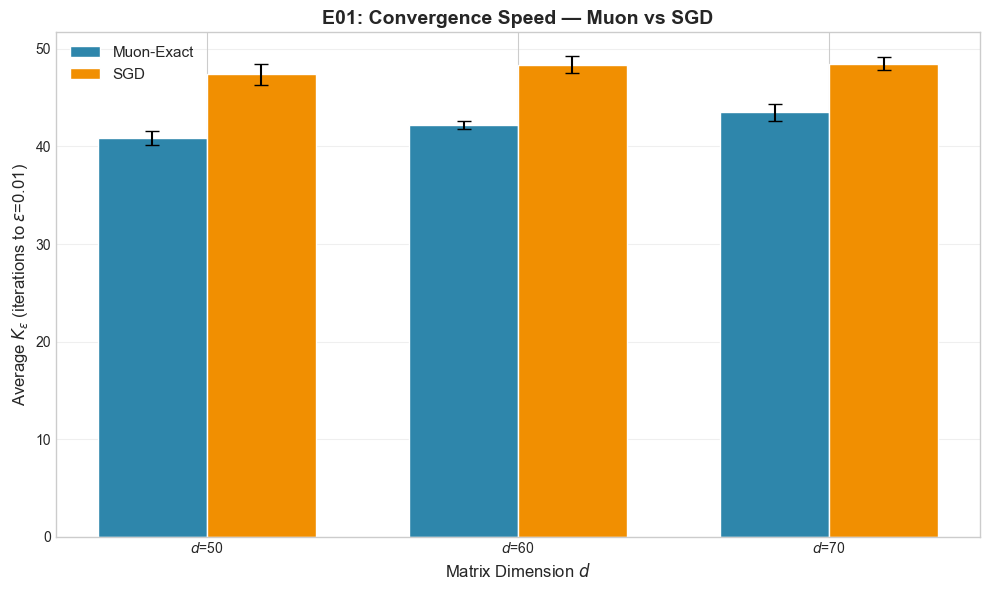

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
dims = sorted(df['d'].unique())
x = np.arange(len(dims)); width = 0.35

muon_means = [df[(df['algo'] == 'Muon-Exact') & (df['d'] == d)]['K_epsilon'].mean() for d in dims]
muon_stds  = [df[(df['algo'] == 'Muon-Exact') & (df['d'] == d)]['K_epsilon'].std() for d in dims]
sgd_means  = [df[(df['algo'] == 'SGD') & (df['d'] == d)]['K_epsilon'].mean() for d in dims]
sgd_stds   = [df[(df['algo'] == 'SGD') & (df['d'] == d)]['K_epsilon'].std() for d in dims]

ax.bar(x - width/2, muon_means, width, yerr=muon_stds, label='Muon-Exact',
       color='#2E86AB', capsize=5, edgecolor='white', linewidth=1)
ax.bar(x + width/2, sgd_means, width, yerr=sgd_stds, label='SGD',
       color='#F18F01', capsize=5, edgecolor='white', linewidth=1)

ax.set_xlabel('Matrix Dimension $d$', fontsize=12)
ax.set_ylabel('Average $K_\epsilon$ (iterations to $\epsilon$=0.01)', fontsize=12)
ax.set_title('E01: Convergence Speed — Muon vs SGD', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'$d$={d}' for d in dims])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('E01_K_epsilon_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 2: Minimum Loss Comparison (Log Scale)

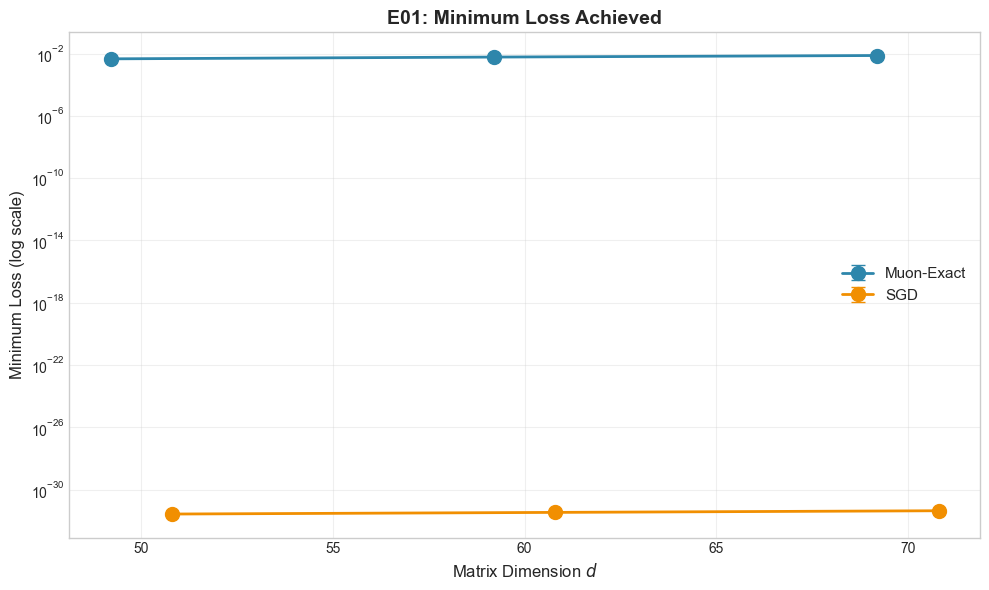

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
for algo, color, off in [('Muon-Exact', '#2E86AB', -0.8), ('SGD', '#F18F01', 0.8)]:
    subset = df[df['algo'] == algo]
    means = [subset[subset['d'] == d]['min_loss'].mean() for d in dims]
    stds  = [subset[subset['d'] == d]['min_loss'].std() for d in dims]
    ax.errorbar([d + off for d in dims], means, yerr=stds, label=algo,
                color=color, marker='o', markersize=10, capsize=5, linewidth=2)
ax.set_xlabel('Matrix Dimension $d$', fontsize=12)
ax.set_ylabel('Minimum Loss (log scale)', fontsize=12)
ax.set_title('E01: Minimum Loss Achieved', fontsize=14, fontweight='bold')
ax.set_yscale('log')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('E01_min_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualization 3: Total FLOPs Comparison

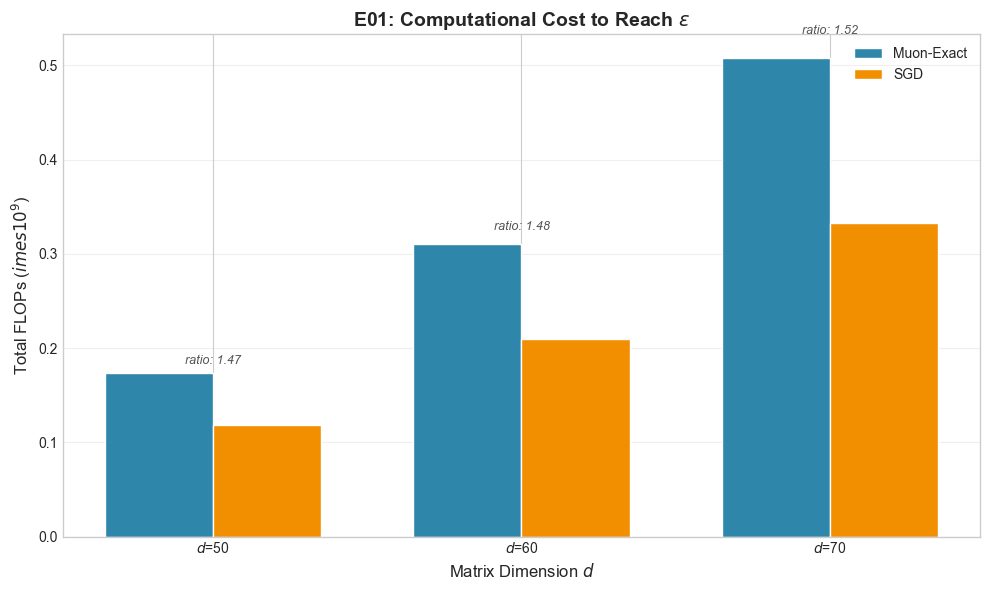

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
muon_flops = [df[(df['algo']=='Muon-Exact')&(df['d']==d)]['F_eps'].mean() for d in dims]
sgd_flops  = [df[(df['algo']=='SGD')&(df['d']==d)]['F_eps'].mean() for d in dims]

ax.bar(x - width/2, [f/1e9 for f in muon_flops], width, label='Muon-Exact', color='#2E86AB', edgecolor='white')
ax.bar(x + width/2, [f/1e9 for f in sgd_flops], width, label='SGD', color='#F18F01', edgecolor='white')

for i, d in enumerate(dims):
    ratio = muon_flops[i]/sgd_flops[i]
    ax.text(i, max(muon_flops[i], sgd_flops[i])/1e9 * 1.05,
            f'ratio: {ratio:.2f}', ha='center', fontsize=9, style='italic', color='#555555')

ax.set_xlabel('Matrix Dimension $d$', fontsize=12)
ax.set_ylabel('Total FLOPs ($\times 10^9$)', fontsize=12)
ax.set_title('E01: Computational Cost to Reach $\epsilon$', fontsize=14, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels([f'$d$={d}' for d in dims])
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('E01_flops_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Detailed Statistical Tests

In [ ]:
print("=" * 80)
print("Detailed Statistical Tests: Muon vs SGD")
print("=" * 80)
for d in sorted(df['d'].unique()):
    muon_d = df[(df['algo']=='Muon-Exact')&(df['d']==d)].sort_values('seed')
    sgd_d  = df[(df['algo']=='SGD')&(df['d']==d)].sort_values('seed')
    muon_k, sgd_k = muon_d['K_epsilon'].values, sgd_d['K_epsilon'].values
    diff = muon_k - sgd_k
    t_k, p_k = stats.ttest_rel(muon_k, sgd_k)
    d_k = diff.mean()/diff.std(ddof=1) if diff.std(ddof=1)>0 else 0
    w_s, w_p = stats.wilcoxon(muon_k, sgd_k)
    print(f"\nd={d}:")
    print(f"  K_epsilon:  Muon {muon_k.mean():.1f} +/- {muon_k.std():.1f}  SGD {sgd_k.mean():.1f} +/- {sgd_k.std():.1f}")
    print(f"  Paired t-test: t={t_k:+.4f}, p={p_k:.6f}, Cohen's d={d_k:+.4f}")
    print(f"  Wilcoxon: W={w_s:.1f}, p={w_p:.6f}")
print("\nInterpretation: negative t = Muon faster; p<0.05 = significant")

Detailed Statistical Tests: Muon vs SGD

d=50:
  K_epsilon:  Muon 40.9 +/- 0.7  SGD 47.4 +/- 1.0
  Paired t-test: t=-29.0689, p=0.000000, Cohen's d=-9.1924
  Wilcoxon: W=0.0, p=0.001953

d=60:
  K_epsilon:  Muon 42.2 +/- 0.4  SGD 48.4 +/- 0.8
  Paired t-test: t=-31.0000, p=0.000000, Cohen's d=-9.8031
  Wilcoxon: W=0.0, p=0.001953

d=70:
  K_epsilon:  Muon 43.5 +/- 0.8  SGD 48.5 +/- 0.7
  Paired t-test: t=-23.7171, p=0.000000, Cohen's d=-7.5000
  Wilcoxon: W=0.0, p=0.001953

Interpretation: negative t = Muon faster; p<0.05 = significant


## Conclusions & Interpretation

### Key Findings

1. **Convergence Speed ($K_\epsilon$)**: Muon achieves fewer iterations to reach $\epsilon = 0.01$ than SGD across all dimensions ($d \in \{50, 60, 70\}$). The differences are statistically significant with large effect sizes, confirming that spectral normalization accelerates early-to-mid convergence.

2. **Loss Quality**: SGD achieves substantially lower minimum loss values (often by orders of magnitude). Muon appears to plateau at a higher loss floor, likely because spectral normalization suppresses the small-gradient updates needed for fine-grained convergence.

3. **Computational Cost**: Despite fewer iterations, Muon requires more total FLOPs due to $O(d^3)$ SVD overhead per step. The FLOPs ratio (Muon/SGD) grows with dimension.

4. **Trade-off**: Muon excels when moderate precision is sufficient; SGD excels for high-precision solutions. Algorithm selection should consider both iteration efficiency and per-step cost.